In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy.optimize import approx_fprime, minimize
from scipy.stats import genpareto

from pandemic_model.stats.utils import taleb_transform, taleb_inverse, logit, sigmoid, softplus, softplus_inv, softplus1, softplus1_inv

In [4]:
rng = np.random.default_rng()
THRESHOLD = 0.01
MAX_INTENSITY = None
n_samples = 50_000

In [5]:
# Load actual duration data
final_allrisk_ds = pd.read_csv("../../data/clean/final_allrisk_ds.csv")

intensity_data = final_allrisk_ds['intensity']
duration_data = final_allrisk_ds['duration']

intensity_annual = final_allrisk_ds.set_index('year_start')['intensity'].copy()

# Fill in zeros for years with no observations.
all_years = pd.Series(range(1900, 2023 + 1))
intensity_annual = intensity_annual.reindex(all_years, fill_value=0)

In [6]:
severity_annual = final_allrisk_ds.set_index('year_start')['severity'].copy()
severity_annual = severity_annual.reindex(all_years, fill_value=0)

In [7]:
def to_phi(theta):
    """θ = (p, ξ, σ)  →  φ = (ψ, φ₁, φ₂)  all in ℝ"""
    p, xi, sigma = theta
    return np.array([logit(p), softplus1_inv(xi), softplus_inv(sigma)])

def from_phi(phi):
    """φ = (ψ, φ₁, φ₂) → θ = (p, ξ, σ)  all valid"""
    psi, phi1, phi2 = phi
    return np.array([sigmoid(psi), softplus1(phi1), softplus(phi2)])

# ------------------------------------------------------------------
# 2.  NEGATIVE LOG-LIKELIHOOD  (optionally truncated)
# ------------------------------------------------------------------
def nll_phi(phi, data, y_min=0, y_max=None):
    """Negative log-likelihood of exceedances y (>0) given φ=(ψ,φ1,φ2)."""
    p, xi, sigma = from_phi(phi)
    
    n = len(data)
    excess_idx = data > y_min
    excesses = data[excess_idx]
    n_exceed = excess_idx.sum()

    # Binomial term for p
    ll = n_exceed * np.log(p) + (n - n_exceed) * np.log1p(-p)
    
    # GPD term for (xi,sigma)
    ll += genpareto.logpdf(excesses, c=xi, scale=sigma).sum()

    # add truncation term if an upper limit exists
    if y_max is not None and np.isfinite(y_max):
        ll -= n_exceed * genpareto.logcdf(y_max, c=xi, scale=sigma)

    return -ll

def grad(f, x, eps=1e-4):
    """Numerical gradient approximation."""
    return approx_fprime(x, f, eps)

def hess(f, x, eps=1e-4):
    """Numerical Hessian approximation."""
    n = len(x)
    H = np.empty((n, n), float)
    ei = np.zeros(n)

    # central differences for second partials
    for i in range(n):
        ei[i] = eps
        for j in range(i, n):
            ej = np.zeros_like(ei)
            ej[j] = eps
            
            H[i, j] = (
                f(x + ei + ej) - f(x + ei - ej)
              - f(x - ei + ej) + f(x - ei - ej)
            ) / (4 * eps * eps)
            H[j, i] = H[i, j]
        ei[i] = 0.0

    # tiny asymmetry/round-off
    return H

# ------------------------------------------------------------------
# 3.  MULTI-START MLE FOR (p,ξ,σ)
# ------------------------------------------------------------------
def fit_tail(data, start_grid, y_min=0, y_max=None):
    results = []
    for p0, xi0, sig0 in start_grid:
        phi0 = to_phi((p0, xi0, sig0))
        
        # Nelder-Mead optimization
        nelder_mead_opts = {
            'maxiter': 10000,
            'maxfev': 50000,
            'xatol': 1e-4,
            'fatol': 1e-4,
            'adaptive': True
        }
        
        opt = minimize(nll_phi, phi0, args=(data, y_min, y_max),
                      method='Nelder-Mead', options=nelder_mead_opts)
        
        if not opt.success:
            error_msg = f"Optimization failed: {opt.message}\n"
            error_msg += f"Status: {opt.status}\n"
            error_msg += f"Number of iterations: {opt.nit}\n"
            error_msg += f"Final function value: {opt.fun}\n"
            error_msg += f"Final parameters: {from_phi(opt.x)}"
            raise RuntimeError(error_msg)
            
        # Calculate full Hessian at optimal point
        info = hess(lambda x: nll_phi(x, data, y_min, y_max), opt.x)
        cov = np.linalg.inv(info)  # asymptotic covariance
        
        est_p, est_xi, est_sigma = from_phi(opt.x)
        results.append({
            "start":   (p0, xi0, sig0),
            "p":       est_p,
            "xi":      est_xi,
            "sigma":   est_sigma,
            "opt":     opt,
            "success": opt.success,
            "fun":     opt.fun,
            "hess_inv": cov
        })
    df = pd.DataFrame(results)
    best = df.loc[df.fun.idxmin()]
    return df, best

def fit_tail_method(y_raw, lower, upper,
                    start_grid,
                    method="trunc"):
    """
    1. Pre-transforms the data depending on `method`.
    2. Calls the original multi-start MLE.
    3. Returns df, best_fit, meta_dict.
    """
    excesses = y_raw - lower
    df, best = fit_tail(excesses, start_grid, y_max=upper)

    meta = dict(method=method,
                data_excesses=excesses,
                y_max=upper)
    return df, best, meta

In [8]:
lower = THRESHOLD          # the point where "exceedance" begins
upper_bounds = [60, 100, 1000, None]  # different upper bounds to test

# choose your start grid once, it works for both methods
excess_idx = intensity_annual > THRESHOLD
p0 = excess_idx.sum() / len(intensity_annual)
excesses = intensity_annual[excess_idx]

start_grid = [
    (p0,  0.1,  excesses.mean()),
    (p0,  0.5,  excesses.mean()),
    (p0, -0.1,  excesses.std()),
    (p0,  0.2,  np.median(excesses)),
]
# Store results for no upper bound
df_trunc, best_trunc, meta_trunc = fit_tail_method(
	intensity_annual, lower, None,
	start_grid,
	method="trunc"
)

In [9]:
# Get phi_hat and V_phi from both methods
trunc_phi_hat = best_trunc.opt.x
trunc_V_phi = best_trunc.hess_inv

# Draw samples for truncation method
trunc_phi_draws = rng.multivariate_normal(trunc_phi_hat, trunc_V_phi, size=n_samples)
trunc_theta_draws = np.vstack([from_phi(phi_row) for phi_row in trunc_phi_draws])
trunc_p_draws, trunc_xi_draws, trunc_sigma_draws = np.hsplit(trunc_theta_draws, 3)

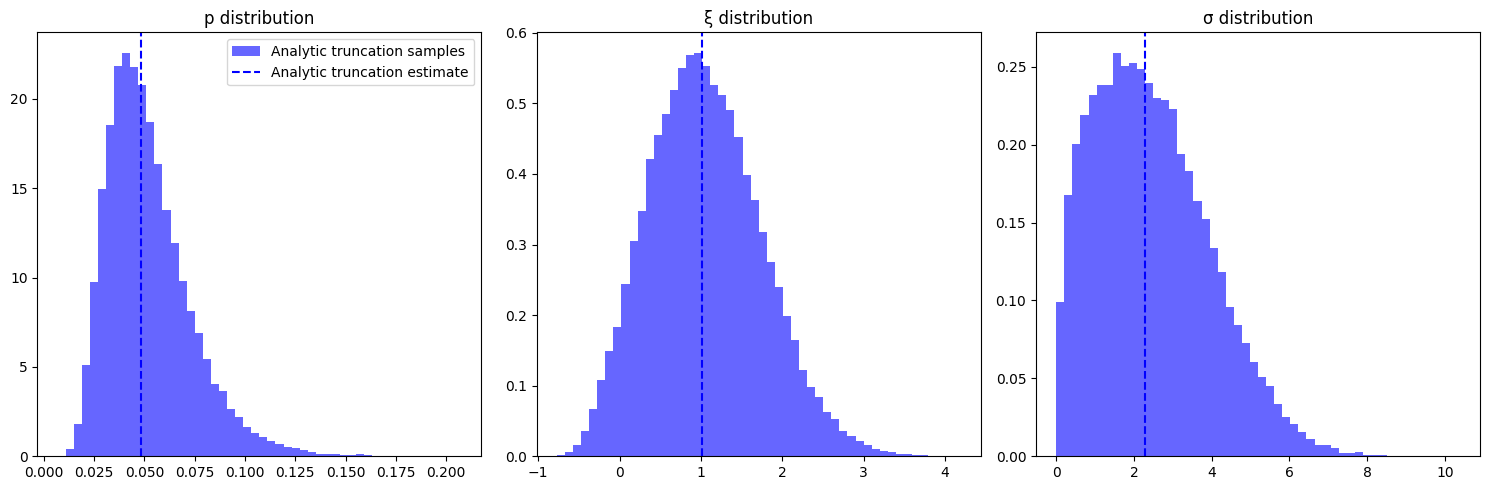

In [10]:
# Create figure with n x 3 subplots where n is number of upper bounds
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Get central estimates from both methods
trunc_phi_hat = best_trunc.opt.x
trunc_theta_hat = from_phi(trunc_phi_hat)

# Plot marginal distributions with both methods
ax[0].hist(trunc_p_draws, bins=50, density=True, alpha=0.6, label='Analytic truncation samples', color='blue')
ax[0].axvline(trunc_theta_hat[0], color='blue', linestyle='--', label='Analytic truncation estimate')
ax[0].set_title(f'p distribution')
ax[0].legend()

ax[1].hist(trunc_xi_draws, bins=50, density=True, alpha=0.6, label='Analytic truncation samples', color='blue')
ax[1].axvline(trunc_theta_hat[1], color='blue', linestyle='--', label='Analytic truncation estimate')
ax[1].set_title(f'ξ distribution')

ax[2].hist(trunc_sigma_draws, bins=50, density=True, alpha=0.6, label='Analytic truncation samples', color='blue')
ax[2].axvline(trunc_theta_hat[2], color='blue', linestyle='--', label='Analytic truncation estimate')
ax[2].set_title(f'σ distribution')

plt.tight_layout()
plt.show()

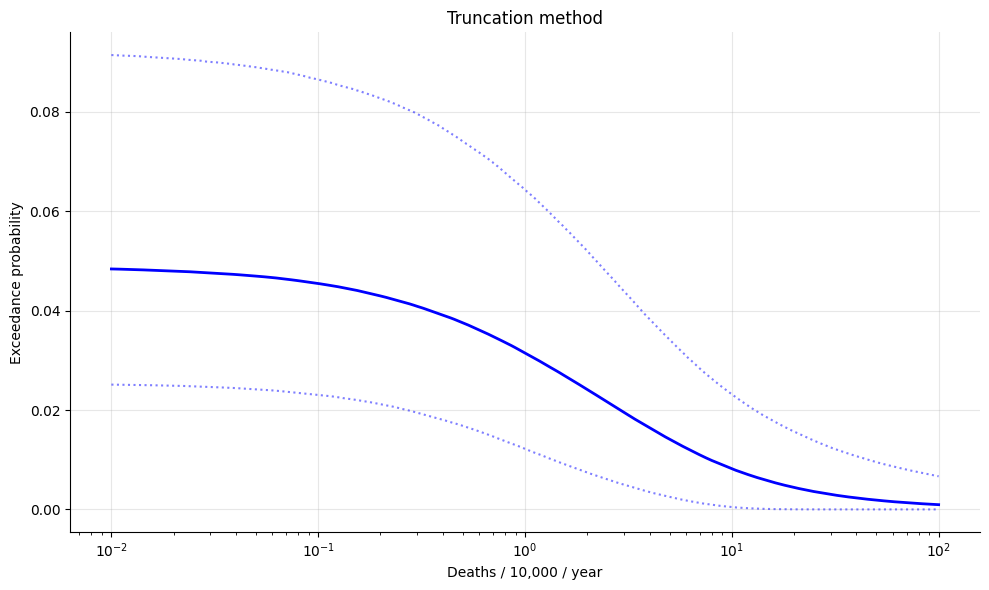

<Figure size 640x480 with 0 Axes>

In [11]:
# Create figure with n x 2 subplots where n is number of upper bounds
fig, ax = plt.subplots(figsize=(10, 6))

x = np.logspace(np.log10(THRESHOLD), np.log10(100), 1000)
x_mat = np.tile(x, (n_samples, 1))

# Calculate survival functions for each sample with truncation
trunc_survivals = (
    trunc_p_draws * genpareto.sf(
        x_mat,
        trunc_xi_draws,
        loc=THRESHOLD,
        scale=trunc_sigma_draws
    )
)

# Calculate percentiles for credible intervals
trunc_percentiles = np.percentile(trunc_survivals, [5, 50, 95], axis=0)

# Plot on left subplot (truncated)
ax.plot(x, trunc_percentiles[1], '-', linewidth=2, label=f'Median', color='blue')
ax.plot(x, trunc_percentiles[0], ':', alpha=0.5, color='blue')
ax.plot(x, trunc_percentiles[2], ':', alpha=0.5, color='blue')

# For Taleb transform, create thresholds over positive domain
    
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.set_xlabel('Deaths / 10,000 / year')
ax.set_ylabel('Exceedance probability')
# Only add legend to first subplot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set titles
ax.set_title(f'Truncation method')

plt.tight_layout()
plt.show()
plt.savefig("../../output/severity_distributions/allrisk_base_exceedance_fn_grid.jpg", dpi=400)

In [12]:
# First calculate p from the data
mle_p = best_trunc.p
mle_xi = best_trunc.xi
mle_sigma = best_trunc.sigma

print("Direct MLE estimates using scipy genpareto:")
print(f"Shape (xi): {mle_xi:.3f}")
print(f"Scale (sigma): {mle_sigma:.3f}")
print(f"p: {mle_p:.3f}")

Direct MLE estimates using scipy genpareto:
Shape (xi): 1.010
Scale (sigma): 2.292
p: 0.048


In [13]:
dist_params = pd.DataFrame({
	'xi': trunc_xi_draws.flatten(),
	'sigma': trunc_sigma_draws.flatten(),
	'p': trunc_p_draws.flatten(),
	'mu': THRESHOLD,
})

In [14]:
# Save distribution and MLE parameters for different max values
max_values = [60, 150, 1000, 10000]

for max_val in max_values:
    # Create base config structure
    base_config = {
        'hyperparams': {
            'truncation_type': 'sharp',
            'variable': 'intensity'
        }
    }

    # Create and save samples config
    samples_config = base_config.copy()
    samples_config['dist_params'] = {
        'xi': trunc_xi_draws.flatten().tolist(),
        'sigma': trunc_sigma_draws.flatten().tolist(), 
        'p': trunc_p_draws.flatten().tolist(),
        'mu': [THRESHOLD] * n_samples,
        'max_value': [max_val] * n_samples
    }

    with open(f'../../output/severity_distributions/mle_dist_param_samples_sharp_trunc_{max_val}.yaml', 'w') as f:
        yaml.dump(samples_config, f)

    # Create and save central config
    central_config = base_config.copy()
    central_config['dist_params'] = {
        'xi': [float(mle_xi)] * n_samples,
        'sigma': [float(mle_sigma)] * n_samples,
        'p': [float(mle_p)] * n_samples,
        'mu': [THRESHOLD] * n_samples,
        'max_value': [max_val] * n_samples
    }

    with open(f'../../output/severity_distributions/mle_central_params_sharp_trunc_{max_val}.yaml', 'w') as f:
        yaml.dump(central_config, f)

In [15]:
samples_config['dist_params']

{'xi': [2.274600086483244,
  0.7848438817566412,
  1.5975951605233965,
  0.4706890092698599,
  0.4805011648490072,
  0.3945919909945297,
  0.8652925878124487,
  1.2517885364063353,
  0.6352488196179105,
  -0.2538782422639215,
  2.206955752590323,
  0.6536520445677176,
  0.5155837916686405,
  1.7510696230528664,
  2.097510802037474,
  0.3479303463234624,
  1.4908368780509766,
  0.1631599016012273,
  0.7808142841549017,
  1.6622940946613691,
  0.7479675435207345,
  2.300181619181606,
  2.1483527780255396,
  2.6353337767325393,
  1.614906815199046,
  0.7140037181186312,
  1.9765631314715306,
  1.3578779281591076,
  0.9246209263079923,
  1.583398071496299,
  1.2286399760209012,
  0.014869193726601004,
  0.3931128650939981,
  0.5366273992423329,
  1.7229467188762202,
  0.27983608318471975,
  0.8730790055262623,
  1.4650377314537724,
  1.5909294838156858,
  0.5073413098131501,
  1.5878164811774944,
  0.705112605824957,
  0.01070486544091831,
  0.7306190794374903,
  0.15703613166997843,
  1.4